- TITLE: REGRESSION EVALUATION FOR THE ABALONE KAGGLE COMPETITION
- Name: Yavo Michel Blaffo
- Type: Predictive Analysis
- Date: March 22, 2026

# Import required libraries and define the diagnostic plotting function
- This block prepares the Python environment for the full regression analysis. 
- It imports the libraries needed for data handling, statistical testing, model fitting, evaluation metrics, and visualization. 

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Helper Functions
- It defines a faster diagnostic plotting function that create the following: 
    - residual, 
    - Q-Q 
    - scale-location 
    - leverage
    - Cook’s distance plots 
- It also uses sampling to improve speed on a large dataset.

In [2]:
def diagnostic_plots(model, model_name, max_points=5000):
    """
    Faster diagnostic plots for large regression models.
    Uses internal studentized residuals instead of external studentized residuals.
    Optionally samples points for plotting speed while preserving diagnostics.
    """

    fitted = np.asarray(model.fittedvalues)
    resid = np.asarray(model.resid)

    influence = model.get_influence()
    studentized = np.asarray(influence.resid_studentized_internal)   # fast
    leverage = np.asarray(influence.hat_matrix_diag)
    cooks = np.asarray(influence.cooks_distance[0])

    n = int(model.nobs)
    p = int(model.df_model) + 1
    leverage_cutoff = 2 * p / n
    cooks_cutoff = 4 / n

    # sample for faster plotting if dataset is large
    if len(fitted) > max_points:
        rng = np.random.default_rng(42)
        idx = np.sort(rng.choice(len(fitted), size=max_points, replace=False))
    else:
        idx = np.arange(len(fitted))

    fitted_s = fitted[idx]
    resid_s = resid[idx]
    studentized_s = studentized[idx]
    leverage_s = leverage[idx]
    cooks_s = cooks[idx]

    lowess = sm.nonparametric.lowess

    # 1. Residuals vs Fitted
    plt.figure(figsize=(8, 5))
    plt.scatter(fitted_s, resid_s, alpha=0.35)
    plt.axhline(0, linestyle="--", linewidth=1)
    if np.unique(fitted_s).size > 1:
        smooth = lowess(resid_s, fitted_s, frac=0.2)
        plt.plot(smooth[:, 0], smooth[:, 1], linewidth=2)
    plt.title(f"Residuals vs Fitted - {model_name}")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()

    # 2. Q-Q Plot
    fig = sm.qqplot(resid, line="45", fit=True)
    plt.title(f"Q-Q Plot - {model_name}")
    plt.tight_layout()
    plt.show()

    # 3. Scale-Location
    plt.figure(figsize=(8, 5))
    scale_y = np.sqrt(np.abs(studentized_s))
    plt.scatter(fitted_s, scale_y, alpha=0.35)
    if np.unique(fitted_s).size > 1 and np.nanstd(scale_y) > 0:
        smooth = lowess(scale_y, fitted_s, frac=0.2)
        plt.plot(smooth[:, 0], smooth[:, 1], linewidth=2)
    plt.title(f"Scale-Location Plot - {model_name}")
    plt.xlabel("Fitted values")
    plt.ylabel("Sqrt(|Studentized residuals|)")
    plt.tight_layout()
    plt.show()

    # 4. Residuals vs Leverage
    plt.figure(figsize=(8, 5))
    plt.scatter(leverage_s, studentized_s, alpha=0.35)
    plt.axhline(3, linestyle="--", linewidth=1)
    plt.axhline(-3, linestyle="--", linewidth=1)
    plt.axvline(leverage_cutoff, linestyle="--", linewidth=1)
    plt.title(f"Residuals vs Leverage - {model_name}")
    plt.xlabel("Leverage")
    plt.ylabel("Studentized residuals")
    plt.tight_layout()
    plt.show()

    # 5. Cook's Distance
    plt.figure(figsize=(8, 5))
    plt.scatter(np.arange(len(cooks_s)), cooks_s, alpha=0.35)
    plt.axhline(cooks_cutoff, linestyle="--", linewidth=1)
    plt.title(f"Cook's Distance - {model_name}")
    plt.xlabel("Observation index")
    plt.ylabel("Cook's distance")
    plt.tight_layout()
    plt.show()

# Load the training, test, and sample submission files
- This block reads the Kaggle Abalone competition files from the local folder path. 
- It standardizes the column names into simpler lowercase names so the dataset is easier to work with during the analysis. 
- It checks all required columns are present in both the training and test files and prints the data dimensions and sex categories to confirm the files were loaded correctly.

In [ ]:
train_path = Path(r"F:/NU/predictive_analysis/week2/assignment2/playground-series-s4e4/train.csv")
test_path = Path(r"F:/NU/predictive_analysis/week2/assignment2/playground-series-s4e4/test.csv")
sample_path = Path(r"F:/NU/predictive_analysis/week2/assignment2/playground-series-s4e4/sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)

rename_map = {
    "Sex": "sex",
    "Length": "length",
    "Diameter": "diameter",
    "Height": "height",
    "Whole weight": "whole_weight",
    "Whole weight.1": "shucked_weight",
    "Whole weight.2": "viscera_weight",
    "Shell weight": "shell_weight",
    "Rings": "rings",
}

train = train.rename(columns=rename_map).copy()
test = test.rename(columns=rename_map).copy()
sample_submission = sample_submission.rename(columns={"Rings": "rings"}).copy()

required_train_cols = {
    "id", "sex", "length", "diameter", "height",
    "whole_weight", "shucked_weight", "viscera_weight", "shell_weight", "rings"
}
required_test_cols = {
    "id", "sex", "length", "diameter", "height",
    "whole_weight", "shucked_weight", "viscera_weight", "shell_weight"
}

assert required_train_cols.issubset(train.columns), "Training file is missing required columns."
assert required_test_cols.issubset(test.columns), "Test file is missing required columns."

sex_levels = sorted(train["sex"].dropna().unique().tolist())

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sex levels:", sex_levels)
train.head()

Train shape: (90615, 10)
Test shape: (60411, 9)
Sex levels: ['F', 'I', 'M']


,id,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


# Produce complete descriptive summary tables for deep study
### Complete statistical summary tables for deep study
- This block creates a full descriptive overview of the dataset. 
- It summarizes the size of the training and test files. 
- It checks for missing values and duplicate rows.
- It reports descriptive statistics for all numeric variables. 
- It shows the category counts and proportions for the sex variable, and computes the correlation matrix. 
- This helps build an initial understanding of the data before modeling begins.

In [16]:
dataset_summary_table = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train), len(test)],
    "columns": [train.shape[1], test.shape[1]],
    "missing_values_total": [int(train.isna().sum().sum()), int(test.isna().sum().sum())],
    "duplicate_rows": [int(train.duplicated().sum()), int(test.duplicated().sum())]
})

numeric_cols = [
    "length", "diameter", "height", "whole_weight",
    "shucked_weight", "viscera_weight", "shell_weight"
]

numeric_summary_table = train[numeric_cols + ["rings"]].describe().T
numeric_summary_table["skew"] = train[numeric_cols + ["rings"]].skew()
numeric_summary_table["kurtosis"] = train[numeric_cols + ["rings"]].kurt()

categorical_summary_table = (
    train["sex"]
    .value_counts(dropna=False)
    .rename_axis("sex")
    .reset_index(name="count")
)
categorical_summary_table["proportion"] = categorical_summary_table["count"] / len(train)

correlation_table = train[numeric_cols + ["rings"]].corr(numeric_only=True).round(4)

print("DATASET SUMMARY TABLE")
print(dataset_summary_table)

print("\nNUMERIC SUMMARY TABLE")
print(numeric_summary_table.round(4))

print("\nCATEGORICAL SUMMARY TABLE")
print(categorical_summary_table)

print("\nCORRELATION TABLE")
print(correlation_table)

DATASET SUMMARY TABLE
  dataset   rows  columns  missing_values_total  duplicate_rows
0   train  90615       10                     0               0
1    test  60411        9                     0               0

NUMERIC SUMMARY TABLE
                  count    mean     std     min     25%     50%      75%  \
length          90615.0  0.5171  0.1182  0.0750  0.4450  0.5450   0.6000   
diameter        90615.0  0.4017  0.0980  0.0550  0.3450  0.4250   0.4700   
height          90615.0  0.1355  0.0380  0.0000  0.1100  0.1400   0.1600   
whole_weight    90615.0  0.7890  0.4577  0.0020  0.4190  0.7995   1.0675   
shucked_weight  90615.0  0.3408  0.2044  0.0010  0.1775  0.3300   0.4630   
viscera_weight  90615.0  0.1694  0.1009  0.0005  0.0865  0.1660   0.2325   
shell_weight    90615.0  0.2259  0.1302  0.0015  0.1200  0.2250   0.3050   
rings           90615.0  9.6968  3.1762  1.0000  8.0000  9.0000  11.0000   

                    max    skew  kurtosis  
length           0.8150 -0.7320   

# Engineer features for the two regression models
### Model 1 = main effects OLS with dummy variables for sex
### Model 2 = enhanced OLS with centered predictors, polynomial terms,
####           interaction terms, and log1p target for RMSLE alignment
- This block creates the predictor sets used by the two OLS models. 
- The first model uses only the main numeric predictors and dummy variables for sex. 
- The second model expands the feature space by centering the numeric predictors, adding polynomial terms, interaction terms, and a ratio feature, and then combines them with the sex dummy variables. - This prepares both a simple baseline model and a more flexible enhanced model for later comparison.

In [17]:
main_effect_features = [
    "length", "diameter", "height",
    "whole_weight", "shucked_weight", "viscera_weight", "shell_weight"
]

feature_means = train[main_effect_features].mean().to_dict()

def prepare_features(df, feature_means, sex_levels):
    df = df.copy()

    for col in main_effect_features:
        df[f"{col}_c"] = df[col] - feature_means[col]

    df["length_sq_c"] = df["length_c"] ** 2
    df["diameter_sq_c"] = df["diameter_c"] ** 2
    df["height_sq_c"] = df["height_c"] ** 2
    df["length_x_diameter_c"] = df["length_c"] * df["diameter_c"]
    df["whole_x_shell_c"] = df["whole_weight_c"] * df["shell_weight_c"]
    df["weight_ratio_shell_whole"] = np.where(
        df["whole_weight"] > 0,
        df["shell_weight"] / df["whole_weight"],
        0
    )

    sex_cat = pd.Categorical(df["sex"], categories=sex_levels)
    sex_dummies = pd.get_dummies(sex_cat, prefix="sex", drop_first=True, dtype=float)

    model1_num = df[main_effect_features].copy()

    model2_num = df[
        [f"{c}_c" for c in main_effect_features] +
        [
            "length_sq_c",
            "diameter_sq_c",
            "height_sq_c",
            "length_x_diameter_c",
            "whole_x_shell_c",
            "weight_ratio_shell_whole"
        ]
    ].copy()

    X1 = pd.concat([model1_num, sex_dummies], axis=1)
    X2 = pd.concat([model2_num, sex_dummies], axis=1)

    X1 = sm.add_constant(X1, has_constant="add").astype(float)
    X2 = sm.add_constant(X2, has_constant="add").astype(float)

    return X1, X2, df

X1_all, X2_all, train_fe = prepare_features(train, feature_means, sex_levels)
X1_test, X2_test, test_fe = prepare_features(test, feature_means, sex_levels)

y_raw = train["rings"].astype(float)
y_log = np.log1p(y_raw)

print("Model 1 design matrix shape:", X1_all.shape)
print("Model 2 design matrix shape:", X2_all.shape)

Model 1 design matrix shape: (90615, 10)
Model 2 design matrix shape: (90615, 16)


# Define helper functions for regression performance evaluation
- This block creates helper functions used to evaluate the regression models. 
- It defines a function for RMSLE, a function for adjusted R-squared, and a function that combines the following: 
    - RMSE 
    - MAE 
    - R-squared 
    - adjusted R-squared 
    - and RMSLE 
- All the metrics are placed into one summary output. 

In [18]:
def rmsle_score(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true), 0, None)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def adjusted_r2(r2, n, p):
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def regression_metrics(y_true, y_pred, p):
    n = len(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({
        "n_obs": n,
        "n_predictors": p,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Adjusted_R2": adjusted_r2(r2, n, p),
        "RMSLE": rmsle_score(y_true, y_pred)
    })

# Split the training data and fit the two OLS models
- This block separates the training dataset into training and validation subsets so that model performance can be evaluated fairly. 
- It fits the first OLS model on the raw target variable and fits the second OLS model on the log-transformed target to better align with RMSLE. 
- The validation predictions are transformed back when needed, and a comparison table is produced to identify which model performs better on the validation set.

In [ ]:
train_idx, valid_idx = train_test_split(train.index, test_size=0.2, random_state=42)

X1_train = X1_all.loc[train_idx]
X1_valid = X1_all.loc[valid_idx]

X2_train = X2_all.loc[train_idx]
X2_valid = X2_all.loc[valid_idx]

y_train_raw = y_raw.loc[train_idx]
y_valid_raw = y_raw.loc[valid_idx]
y_train_log = y_log.loc[train_idx]

model1 = sm.OLS(y_train_raw, X1_train).fit()
model2 = sm.OLS(y_train_log, X2_train).fit()

pred1_valid = np.clip(model1.predict(X1_valid), 0, None)
pred2_valid = np.clip(np.expm1(model2.predict(X2_valid)), 0, None)

comparison_table = pd.DataFrame({
    "Model_1_Main_Effects_OLS": regression_metrics(y_valid_raw, pred1_valid, X1_train.shape[1] - 1),
    "Model_2_Enhanced_OLS_log_target": regression_metrics(y_valid_raw, pred2_valid, X2_train.shape[1] - 1)
}).T

best_model_name = comparison_table["RMSLE"].idxmin()

print("MODEL COMPARISON TABLE")
print(comparison_table.round(6))
print("\nBest model selected by validation RMSLE:", best_model_name)

MODEL COMPARISON TABLE
                                   n_obs  n_predictors      RMSE       MAE  \
Model_1_Main_Effects_OLS         18123.0           9.0  2.023216  1.392874   
Model_2_Enhanced_OLS_log_target  18123.0          15.0  2.007604  1.345309   

                                       R2  Adjusted_R2     RMSLE  
Model_1_Main_Effects_OLS         0.601513     0.601315  0.166774  
Model_2_Enhanced_OLS_log_target  0.607639     0.607314  0.160735  

Best model selected by validation RMSLE: Model_2_Enhanced_OLS_log_target


# Define helper functions for coefficient tables, VIF, assumptions, and influence
- This block builds reusable functions that summarize the fitted models in a structured way. 
- It creates coefficient tables, multicollinearity tables using VIF, assumption summary tables based on statistical tests, and influence tables that identify potentially influential observations.

In [11]:
def coefficient_table(model):
    conf = model.conf_int()
    return pd.DataFrame({
        "term": model.params.index,
        "coefficient": model.params.values,
        "std_error": model.bse.values,
        "t_value": model.tvalues.values,
        "p_value": model.pvalues.values,
        "ci_lower_95": conf[0].values,
        "ci_upper_95": conf[1].values
    }).sort_values(by="p_value", kind="stable")

def vif_table(X):
    X_no_const = X.drop(columns=["const"]).copy()
    vif_df = pd.DataFrame({
        "feature": X_no_const.columns,
        "VIF": [variance_inflation_factor(X_no_const.values, i) for i in range(X_no_const.shape[1])]
    }).sort_values(by="VIF", ascending=False, kind="stable")
    return vif_df

def assumption_summary(model, X_train, label):
    resid = model.resid
    exog = model.model.exog

    bp_lm, bp_lm_pvalue, bp_fvalue, bp_f_pvalue = het_breuschpagan(resid, exog)
    jb_stat, jb_pvalue, skew, kurtosis = sm.stats.jarque_bera(resid)
    dw = sm.stats.stattools.durbin_watson(resid)

    if len(resid) > 5000:
        shapiro_sample = np.random.default_rng(42).choice(np.asarray(resid), size=5000, replace=False)
    else:
        shapiro_sample = np.asarray(resid)
    shapiro_stat, shapiro_pvalue = stats.shapiro(shapiro_sample)

    p = int(model.df_model) + 1
    n = int(model.nobs)

    return pd.Series({
        "model": label,
        "n_obs": n,
        "n_parameters_including_intercept": p,
        "AIC": model.aic,
        "BIC": model.bic,
        "Durbin_Watson": dw,
        "Breusch_Pagan_LM_pvalue": bp_lm_pvalue,
        "Breusch_Pagan_F_pvalue": bp_f_pvalue,
        "Jarque_Bera_pvalue": jb_pvalue,
        "Shapiro_pvalue": shapiro_pvalue,
        "Residual_Skew": skew,
        "Residual_Kurtosis": kurtosis,
        "Condition_Number": np.linalg.cond(X_train.values)
    })

def influence_table(model, original_index, top_n=25):
    influence = model.get_influence()

    leverage = np.asarray(influence.hat_matrix_diag)
    cooks = np.asarray(influence.cooks_distance[0])
    studentized = np.asarray(influence.resid_studentized_internal)

    fitted = np.asarray(model.fittedvalues)
    resid = np.asarray(model.resid)
    row_index = np.asarray(original_index)

    n = int(model.nobs)
    p = int(model.df_model) + 1

    leverage_cutoff = 2 * p / n
    cooks_cutoff = 4 / n

    outlier_flag = np.abs(studentized) > 3
    high_leverage_flag = leverage > leverage_cutoff
    high_cooks_flag = cooks > cooks_cutoff

    influence_df = pd.DataFrame({
        "row_index": row_index,
        "fitted": fitted,
        "residual": resid,
        "studentized_residual": studentized,
        "leverage": leverage,
        "cooks_distance": cooks,
        "outlier_flag_abs_studentized_gt_3": outlier_flag,
        "high_leverage_flag": high_leverage_flag,
        "high_cooks_flag": high_cooks_flag
    })

    if top_n is not None and top_n < len(influence_df):
        top_idx = np.argpartition(cooks, -top_n)[-top_n:]
        influence_df = influence_df.iloc[top_idx].sort_values(
            by="cooks_distance", ascending=False, kind="stable"
        )
    else:
        influence_df = influence_df.sort_values(
            by="cooks_distance", ascending=False, kind="stable"
        )

    return influence_df.reset_index(drop=True), leverage_cutoff, cooks_cutoff

# Generate complete statistical tables for both fitted models
- This block applies the helper functions to both models and produces the main statistical outputs for deeper study. 
- It builds coefficient tables, VIF tables, assumption summary tables, influence summaries, and the top influential observations for each model.
- This section is used to evaluate significance, collinearity, residual behavior, and influential points in a systematic way.

In [ ]:
coef_table_model1 = coefficient_table(model1)
coef_table_model2 = coefficient_table(model2)

vif_model1 = vif_table(X1_train)
vif_model2 = vif_table(X2_train)

assumption_table = pd.DataFrame([
    assumption_summary(model1, X1_train, "Model_1_Main_Effects_OLS"),
    assumption_summary(model2, X2_train, "Model_2_Enhanced_OLS_log_target")
])

# only keep top 25 influential observations for speed
influence_model1, leverage_cutoff_1, cooks_cutoff_1 = influence_table(model1, train_idx, top_n=25)
influence_model2, leverage_cutoff_2, cooks_cutoff_2 = influence_table(model2, train_idx, top_n=25)

# recompute fast summary counts directly from the top tables only if needed
# for full counts without heavy computation, we can use a second quick helper
def quick_influence_counts(model):
    influence = model.get_influence()
    leverage = np.asarray(influence.hat_matrix_diag)
    cooks = np.asarray(influence.cooks_distance[0])
    studentized = np.asarray(influence.resid_studentized_internal)

    n = int(model.nobs)
    p = int(model.df_model) + 1

    leverage_cutoff = 2 * p / n
    cooks_cutoff = 4 / n

    return {
        "studentized_residual_abs_gt_3_count": int((np.abs(studentized) > 3).sum()),
        "high_leverage_count": int((leverage > leverage_cutoff).sum()),
        "high_cooks_distance_count": int((cooks > cooks_cutoff).sum()),
        "leverage_cutoff": leverage_cutoff,
        "cooks_distance_cutoff": cooks_cutoff
    }

counts_model1 = quick_influence_counts(model1)
counts_model2 = quick_influence_counts(model2)

influence_summary_table = pd.DataFrame([
    {
        "model": "Model_1_Main_Effects_OLS",
        **counts_model1
    },
    {
        "model": "Model_2_Enhanced_OLS_log_target",
        **counts_model2
    }
])

print("ASSUMPTION SUMMARY TABLE")
print(assumption_table.round(6))

print("\nINFLUENCE SUMMARY TABLE")
print(influence_summary_table.round(6))

print("\nTOP COEFFICIENTS - MODEL 1")
print(coef_table_model1.head(20).round(6))

print("\nTOP COEFFICIENTS - MODEL 2")
print(coef_table_model2.head(20).round(6))

print("\nTOP VIF - MODEL 1")
print(vif_model1.head(20).round(6))

print("\nTOP VIF - MODEL 2")
print(vif_model2.head(20).round(6))

print("\nTOP 25 INFLUENTIAL OBSERVATIONS - MODEL 1")
print(influence_model1.head(25).round(6))

print("\nTOP 25 INFLUENTIAL OBSERVATIONS - MODEL 2")
print(influence_model2.head(25).round(6))

ASSUMPTION SUMMARY TABLE
                             model  n_obs  n_parameters_including_intercept  \
0         Model_1_Main_Effects_OLS  72492                                10   
1  Model_2_Enhanced_OLS_log_target  72492                                16   

             AIC            BIC  Durbin_Watson  Breusch_Pagan_LM_pvalue  \
0  305331.867143  305423.779458       1.995211                      0.0   
1  -62125.829716  -61978.770012       1.996748                      0.0   

   Breusch_Pagan_F_pvalue  Jarque_Bera_pvalue  Shapiro_pvalue  Residual_Skew  \
0                     0.0                 0.0             0.0       1.432969   
1                     0.0                 0.0             0.0       0.368317   

   Residual_Kurtosis  Condition_Number  
0           9.606907        153.238772  
1           8.180989       5189.643684  

INFLUENCE SUMMARY TABLE
                             model  studentized_residual_abs_gt_3_count  \
0         Model_1_Main_Effects_OLS             

# Create diagnostic plots for both models
- This block produces visual diagnostic plots for the two fitted regression models. 
- The plots are used to assess linearity, residual spread, normality, leverage, and influence. 
- These visuals complement the earlier statistical tests and provide a clearer picture of whether the model assumptions appear reasonable.

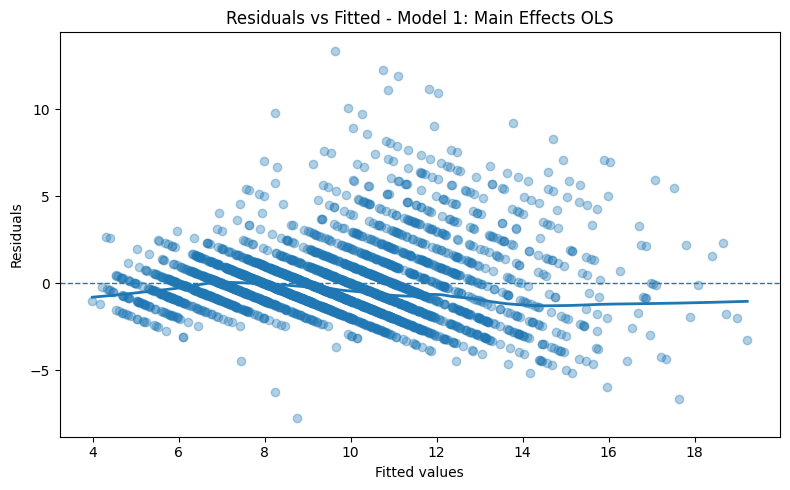

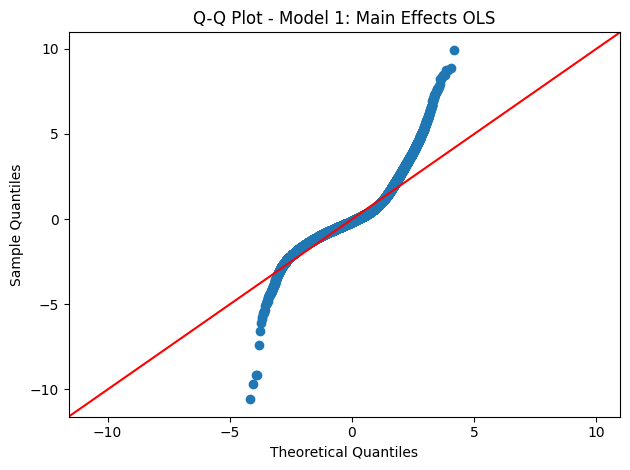

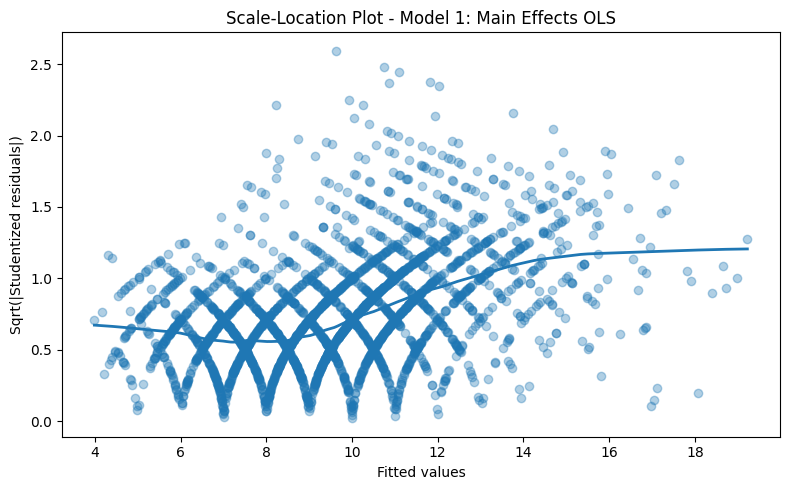

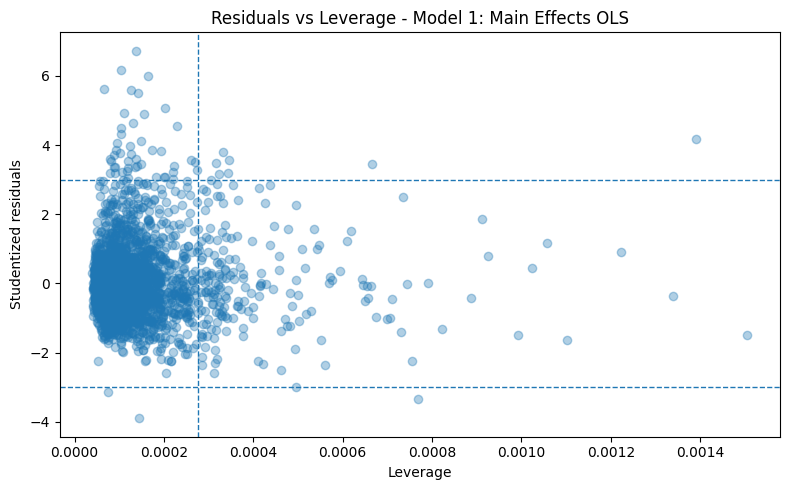

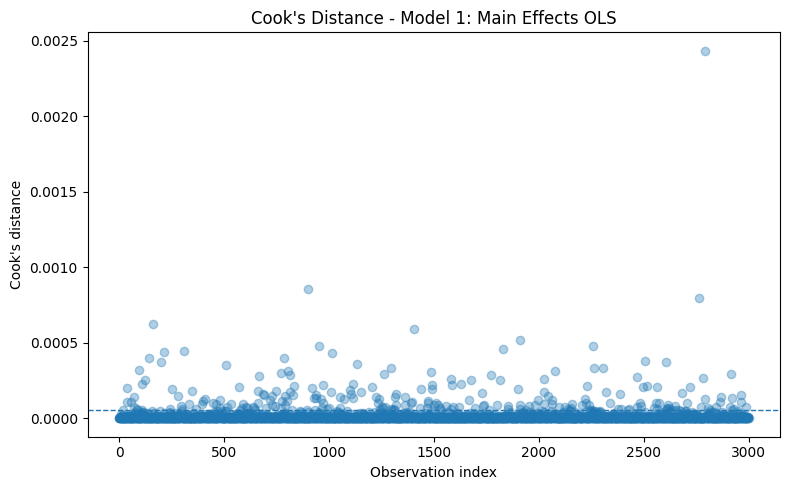

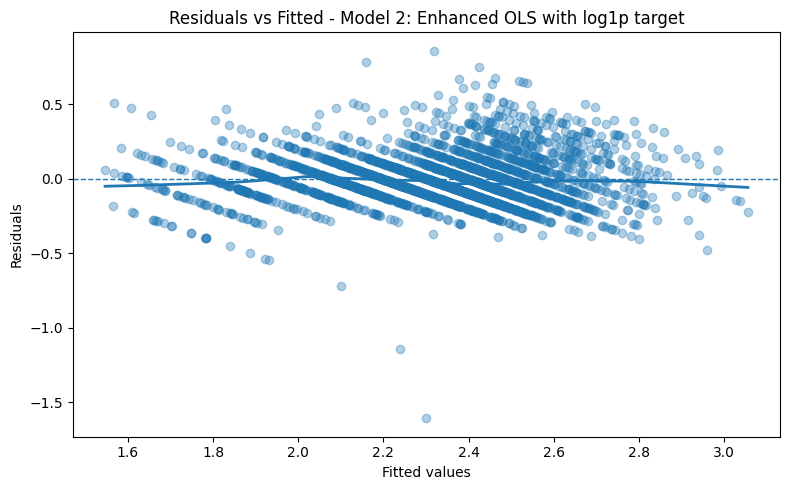

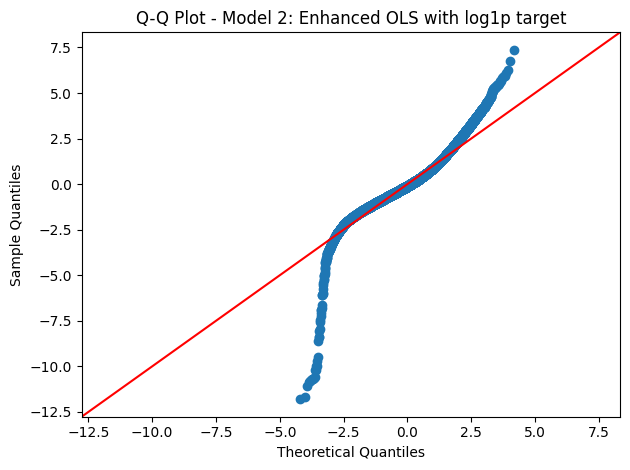

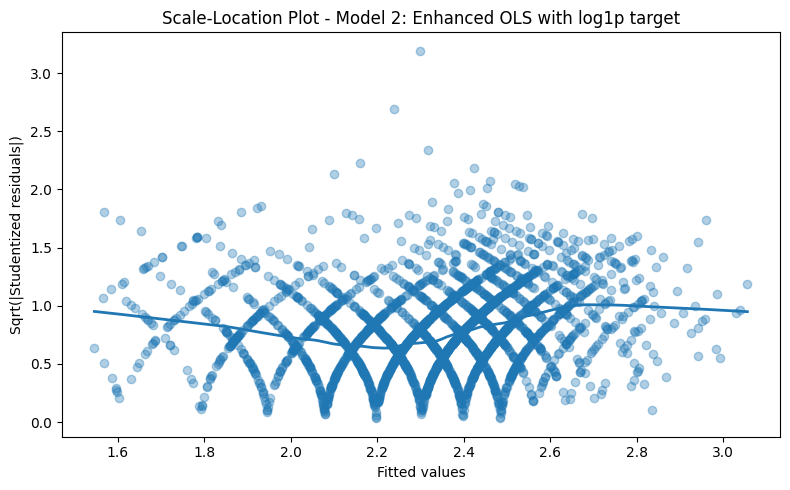

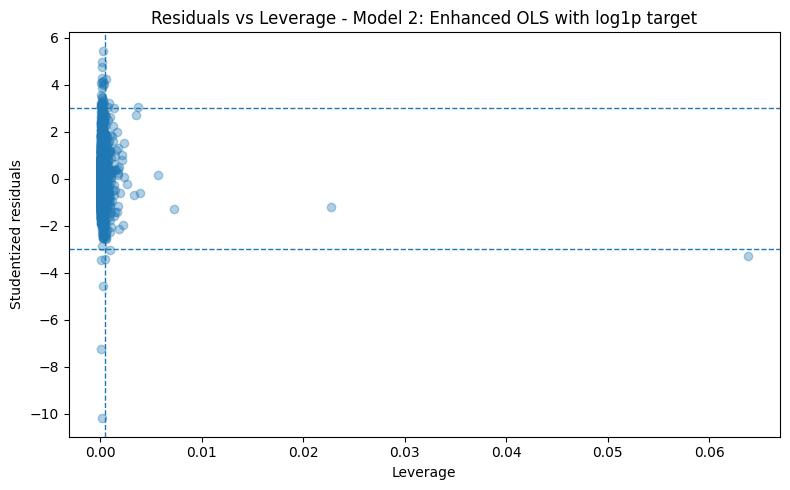

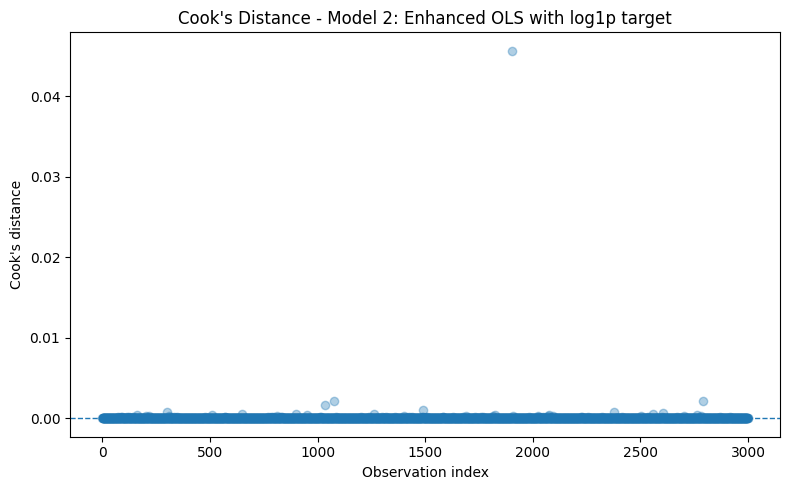

In [ ]:
diagnostic_plots(model1, "Model 1: Main Effects OLS", max_points=3000)
diagnostic_plots(model2, "Model 2: Enhanced OLS with log1p target", max_points=3000)

# Save all statistical tables and output files
- This block creates an output folder and saves all of the important summary tables as CSV files. 
- It exports the dataset summaries, coefficient tables, VIF tables, model comparison table, assumption tables, and influential observation tables. 
- This helps preserve the analytical results for later review, reporting, or submission.

In [14]:
# ------------------------------------------------------------
# Save all statistical tables and the Kaggle-ready submission file
# ------------------------------------------------------------

output_dir = Path("abalone_assignment_outputs")
output_dir.mkdir(exist_ok=True)

dataset_summary_table.to_csv(output_dir / "dataset_summary_table.csv", index=False)
numeric_summary_table.to_csv(output_dir / "numeric_summary_table.csv")
categorical_summary_table.to_csv(output_dir / "categorical_summary_table.csv", index=False)
correlation_table.to_csv(output_dir / "correlation_table.csv")

coef_table_model1.to_csv(output_dir / "coef_table_model1.csv", index=False)
coef_table_model2.to_csv(output_dir / "coef_table_model2.csv", index=False)

vif_model1.to_csv(output_dir / "vif_model1.csv", index=False)
vif_model2.to_csv(output_dir / "vif_model2.csv", index=False)

comparison_table.to_csv(output_dir / "model_comparison_table.csv")
assumption_table.to_csv(output_dir / "assumption_summary_table.csv", index=False)
influence_summary_table.to_csv(output_dir / "influence_summary_table.csv", index=False)
influence_model1.head(25).to_csv(output_dir / "top_influential_points_model1.csv", index=False)
influence_model2.head(25).to_csv(output_dir / "top_influential_points_model2.csv", index=False)

print("All summary tables were saved to:", output_dir)

All summary tables were saved to: abalone_assignment_outputs


# Refit the best model on the full training data and generate the Kaggle submission file
- This block refits whichever model performed best on the validation set using the entire training dataset. 
- It generates predictions for the Kaggle test set, builds the submission DataFrame, and saves it as a CSV file. 
- This is the final production step that turns the selected model into a Kaggle-ready prediction file.

In [19]:
# ------------------------------------------------------------
# Refit the best model on the full training set and generate submission
# ------------------------------------------------------------

if best_model_name == "Model_1_Main_Effects_OLS":
    final_model = sm.OLS(y_raw, X1_all).fit()
    test_predictions = np.clip(final_model.predict(X1_test), 0, None)
else:
    final_model = sm.OLS(y_log, X2_all).fit()
    test_predictions = np.clip(np.expm1(final_model.predict(X2_test)), 0, None)

submission = pd.DataFrame({
    "id": test["id"].values,
    "Rings": test_predictions
})

submission.to_csv(output_dir / "submission.csv", index=False)

print("Sample submission columns:", list(sample_submission.columns))
print("Your submission columns:", list(submission.columns))
print("Rows in test set:", len(test))
print("Rows in submission:", len(submission))
print("\nSubmission file saved to:", output_dir / "submission.csv")

submission.head(10)

Sample submission columns: ['id', 'rings']
Your submission columns: ['id', 'Rings']
Rows in test set: 60411
Rows in submission: 60411

Submission file saved to: abalone_assignment_outputs\submission.csv


,id,Rings
0,90615,8.966156
1,90616,10.075943
2,90617,10.283073
3,90618,10.241345
4,90619,7.667393
5,90620,9.583976
6,90621,12.257602
7,90622,6.111541
8,90623,7.994377
9,90624,11.371690


# Comment Section About the Abalone Dataset
## Development and Comparison of Two Regression Models 
Two models were developed and evaluated on a validation split. The first model was a main effects ordinary least squares regression. This model used the quantitative predictors and dummy-coded values for Sex. This is a standard approach to handling qualitative predictors in regression by converting category levels into indicator variables, allowing the model to estimate group differences relative to a baseline category. 

In the quest for perfection, the second model was basically an enhancement of the first model, which is the ordinary least squares regression built on a log-transformed target. This required us to consider multiple factors such as centered predictors, polynomial terms, interaction terms, and a shell-to-whole weight ratio. This design was revealed to be the stronger one because the residual plots suggest curvature or non-additive structure, transformed predictors, and interaction terms can improve the fit. 

The second model is aligned with this mathematical formula:
log⁡(1+Y)= β_0+β_1 X_i1+β_2 X_i2+⋯+β_p X_ip+ε_i
log⁡(1+〖Rings〗_i )= β_0+β_1 X_i1+β_2 X_i2+⋯+β_p X_ip+ε_i
After fitting the model on the log scale, the predictions were converted back to the original Rings using: 
Y ̂=exp⁡((log⁡(1+Y)) ̂ )-1

The validation results show that Model 2 performed better than Model 1. With the Model 1, we can see that the RMSE is 2.023216, the MAE is 1.392874, the R² is 0.601513, and the RMSLE is 0.166774. Model 2 produced an RMSE of 2.007604, an MAE of 1.345309, an R² of 0.607639, and an RMSLE of 0.160735. 
Because the Kaggle competition emphasizes predictive accuracy, the second module achieved a lower RMSLE, which makes the second model a stronger submission model. One important remark that was noticed here is that the improvement to the model is not huge, but it is consistent across every major validation measure. Therefore, we can assume that the pattern supports the conclusion that the additional structure in Model 2 captured a meaningful signal that the simpler model missed. 

##  Interpretation of the Models
The interpretation is pretty much straightforward. In Model 1, Shell Weight had a strong positive coefficient, Height was strongly positive, and Shucked Weight was strongly negative. The study of the signs indicates that some size-related characteristics increase predicted Rings, while some internal weight measures have behaved differently once the other measurements are held constant. 

In Model 2, the strongest effects came from whole_weight_c, shucked_weight_c, shell_weight_c, height_c, and the interaction whole_x_shell_c. The significant quadratic and interaction terms indicate that the association between physical measurements and Rings is not purely linear or purely additive. That finding demonstrates that the interaction terms help model synergy among predictors and polynomial terms help model curvature in the response relationship. 

The assumptions investigation shows that the second model is stronger, but it also shows that neither model is perfect. First, linearity was improved in Model 2. The inclusion of centered terms, squared terms, and interaction terms reduced the residual structure seen in the simpler specification. This is consistent with the residual plot logic, where patterns in residuals indicate that a strictly linear form is incomplete. 

Second, the independence of errors appears reasonable. The Durbin Watson statistics were 1.995211 for Model 1 and 1.996748 for Model 2. Values near 2 suggest little evidence of serial correlation, so the independence assumption appears acceptable for these data.

Third, collinearity is a major issue. In Model 1, VIF values were extremely high for Diameter, Length, Whole weight, Height, and the other weight variables. In Model 2, several terms were even larger, including the interaction and polynomial terms. The large VIF values indicate problematic multicollinearity because the predictors share overlapping information, which makes individual coefficient estimates less stable even when overall prediction remains useful. This means the model can still predict reasonably well, but coefficient-by-coefficient interpretation should be made with caution.

Fourth, the residual distribution was not fully normal in either model. Both models had Jarque-Bera and Shapiro p-values of 0. Model 1 had a residual skew of 1.432969 and a kurtosis of 9.606907, while Model 2 improved to a skew of 0.368317 and a kurtosis of 8.180989. This shows that the log transformation improved residual symmetry, but normality was still not fully achieved.
Fifth, heteroscedasticity remained present. The Breusch Pagan p values were 0 for both models. That result suggests non constant error variance. Even so, the diagnostic plots and the lower RMSLE for Model 2 indicate that the transformed target improved model behavior relative to Model 1.

Finally, influential observations were present in both models. Model 1 had 1,332 observations with absolute studentized residuals above 3, while Model 2 reduced that count to 860. Model 2 also had fewer high Cook’s distance observations. This means the enhanced model was less affected by extreme cases, even though influential points still remained in the dataset.
Overall, the second model should be selected for the competition because it produced the best validation accuracy and showed better diagnostic behavior than the first model. The final conclusion is that multiple regression with qualitative encoding, transformed predictors, and interaction terms provided a more defensible and more competitive solution for the Abalone prediction task than the simpler main effects model.

## References
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning with applications in Python. Springer Nature.
- Midway, S., & White, J. W. (2025). Testing for normality in regression models: Mistakes abound (but may not matter). Royal Society Open Science, 12(4). https://doi.org/10.1098/rsos.241904 
- Qiu, Y., & Zhang, H. (2024). Prediction of software user interaction data based on the LIGHTGBM model. Proceedings of the 2024 8th International Conference on Big Data and Internet of Things, 226–230. https://doi.org/10.1145/3697355.3697392 
- Rimpler, A., Kiers, H. A. L., & van Ravenzwaaij, D. (2025). To interact or not to interact: The Pros and cons of including interactions in linear regression models. Behavior Research Methods, 57(3). https://doi.org/10.3758/s13428-025-02613-6 
- Shiroshita, A., Yamamoto, N., Saka, N., Shiba, H., Toki, S., Yamamoto, M., Dohi, E., & Kataoka, Y. (2024). Expanding the scope: In-depth review of interaction in Regression Models. Annals of Clinical Epidemiology, 6(2), 25–32. https://doi.org/10.37737/ace.24005 

